<a href="https://colab.research.google.com/github/Vishmika89/Vishmika/blob/main/et3112_Assignment_02_6789.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot (332)new2.png to Screenshot (332)new2.png
Image loaded successfully


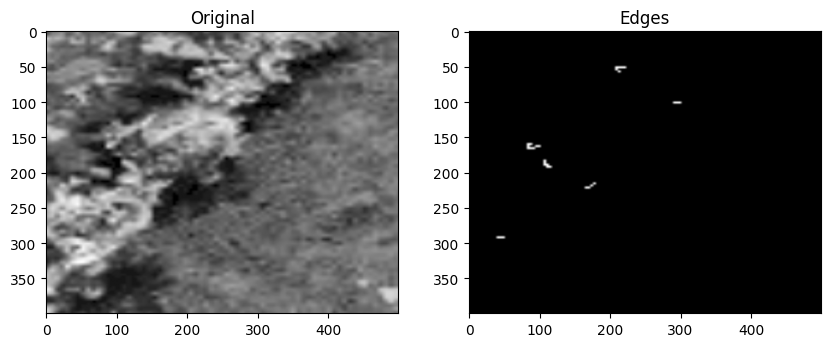

In [45]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
files.upload()

# Read image
img = cv.imread('Screenshot (332)new2.png', cv.IMREAD_GRAYSCALE)

# Check
if img is None:
    print("Image NOT loaded")
else:
    print("Image loaded successfully")

    edges = cv.Canny(img, 550, 690)

    img_resized = cv.resize(img, (500, 400))
    edges_resized = cv.resize(edges, (500, 400))

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img_resized, cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(edges_resized, cmap='gray')
    plt.title("Edges")

    plt.show()

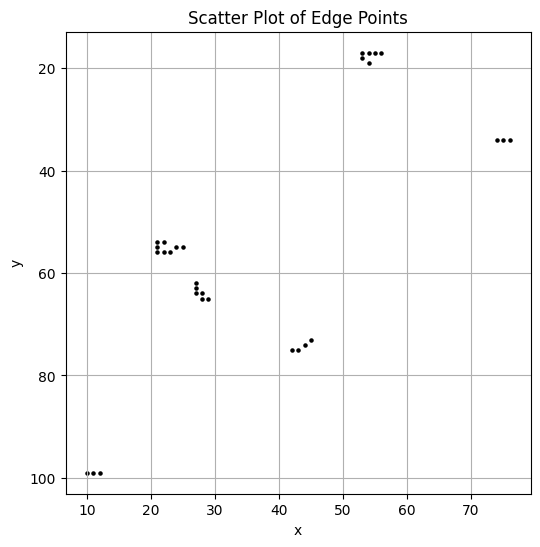

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coordinates of edge points
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='black')

plt.title('Scatter Plot of Edge Points')
plt.xlabel('x')
plt.ylabel('y')

plt.gca().invert_yaxis()  # Makes image-like coordinate view

plt.grid(True)
plt.show()

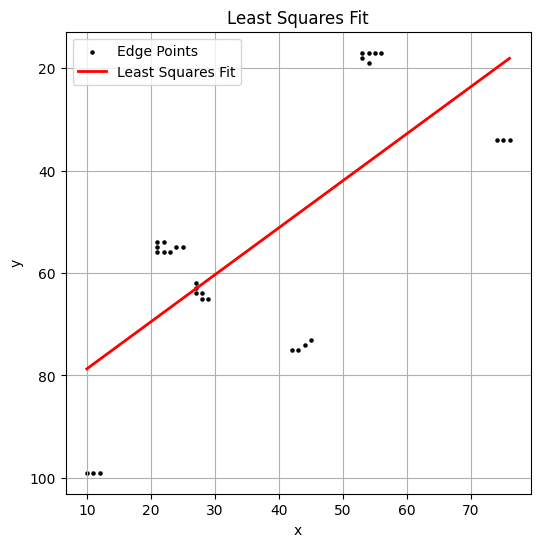

Least Squares slope (m) = -0.9186661449721688
Least Squares intercept (c) = 87.91233639197766


In [47]:
# Q3 - Least Squares Fit

import numpy as np
import matplotlib.pyplot as plt

# Fit line
m_lsf, c_lsf = np.polyfit(x, y, 1)

# Generate fitted line
x_line = np.linspace(np.min(x), np.max(x), 500)
y_line_lsf = m_lsf * x_line + c_lsf

# Plot
plt.figure(figsize=(6, 6))

plt.scatter(x, y, s=5, c='black', label='Edge Points')
plt.plot(x_line, y_line_lsf, 'r', linewidth=2, label='Least Squares Fit')

plt.title('Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')

plt.gca().invert_yaxis()

plt.legend()
plt.grid(True)
plt.show()

# Print values
print("Least Squares slope (m) =", m_lsf)
print("Least Squares intercept (c) =", c_lsf)

In [48]:
theta_lsf = np.degrees(np.arctan(m_lsf))

# Convert to positive angle
theta_lsf = abs(theta_lsf)

print("Estimated Angle (degrees) =", theta_lsf)

Estimated Angle (degrees) = 42.572637492136316


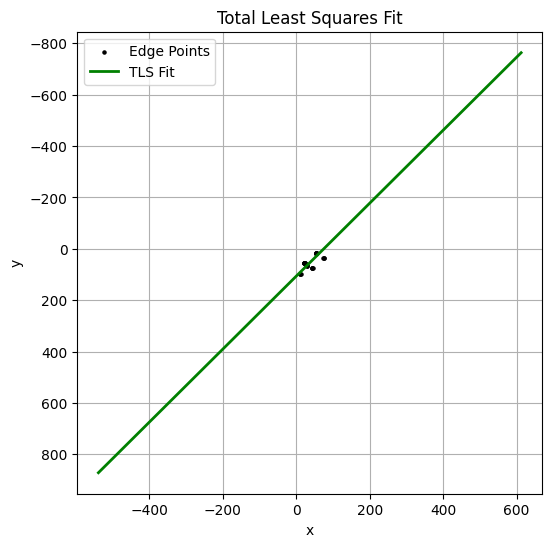

In [49]:
# Q6 - Total Least Squares (TLS)

import numpy as np
import matplotlib.pyplot as plt

# Stack x and y into a single dataset
data = np.vstack((x, y)).T

# Compute mean
mean = np.mean(data, axis=0)

# Center data
data_centered = data - mean

# Apply SVD
U, S, Vt = np.linalg.svd(data_centered)

# Direction vector (principal component)
vx, vy = Vt[0]

# Generate TLS line
t = np.linspace(-1000, 1000, 500)

x_tls = mean[0] + t * vx
y_tls = mean[1] + t * vy

# Plot
plt.figure(figsize=(6, 6))

plt.scatter(x, y, s=5, c='black', label='Edge Points')
plt.plot(x_tls, y_tls, 'g', linewidth=2, label='TLS Fit')

plt.title('Total Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')

plt.gca().invert_yaxis()

plt.legend()
plt.grid(True)
plt.show()

In [50]:
theta_tls = np.degrees(np.arctan2(vy, vx))
theta_tls = abs(theta_tls)

print("TLS Angle (degrees) =", theta_tls)

TLS Angle (degrees) = 125.1463991156671


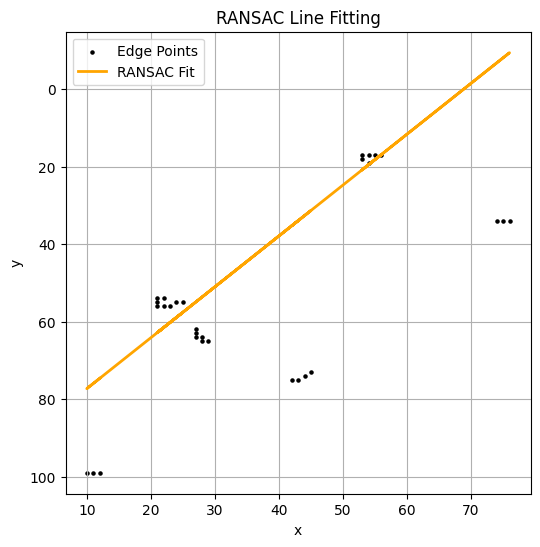

In [51]:
# Q10 - RANSAC Line Fitting

from sklearn.linear_model import RANSACRegressor

# Reshape x for sklearn
x_reshaped = x.reshape(-1, 1)

# Apply RANSAC
ransac = RANSACRegressor()
ransac.fit(x_reshaped, y)

# Predict line
y_ransac = ransac.predict(x_reshaped)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(x, y, s=5, c='black', label='Edge Points')
plt.plot(x, y_ransac, color='orange', linewidth=2, label='RANSAC Fit')

plt.title('RANSAC Line Fitting')
plt.xlabel('x')
plt.ylabel('y')

plt.gca().invert_yaxis()

plt.legend()
plt.grid(True)
plt.show()

In [52]:
m_ransac = ransac.estimator_.coef_[0]

theta_ransac = np.degrees(np.arctan(m_ransac))
theta_ransac = abs(theta_ransac)

print("RANSAC Angle (degrees) =", theta_ransac)

RANSAC Angle (degrees) = 52.70891190810829
